In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Load datasets

df = pd.read_csv(r"C:\Users\USER\PycharmProjects\component2_traffic\traffic_simulation\final_dataset_manual.csv")

# 2️. Define features and target

features = ["duration", "route_length", "average_speed", "time_loss"]
target = "waiting_time"

X = df[features]
y = df[target]


# 3️. Preprocessing

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4️. Train/Test split

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_scaled, y, df.index, test_size=0.2, random_state=42
)


# 5️. Train final Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)


# 6️. Predict waiting time

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)


In [2]:
# 7️. Evaluate model

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Performance:")
print(f"Train RMSE: {train_rmse:.3f}, R²: {train_r2:.3f}")
print(f"Test  RMSE: {test_rmse:.3f}, R²: {test_r2:.3f}")


Linear Regression Performance:
Train RMSE: 15.911, R²: 0.997
Test  RMSE: 17.371, R²: 0.997


In [3]:
from sklearn.metrics import mean_absolute_error

# MAE for test set only
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {test_mae:.3f}")

Test MAE: 12.129


In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

# R2 cross validation
cv_r2 = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2')

# MAE cross validation
cv_mae = -cross_val_score(lr, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')

# RMSE cross validation
cv_rmse = np.sqrt(-cross_val_score(lr, X_scaled, y, cv=5, scoring='neg_mean_squared_error'))

print("Linear Regression Cross Validation (5-Fold):")
print("Mean R2:", cv_r2.mean())
print("Mean MAE:", cv_mae.mean())
print("Mean RMSE:", cv_rmse.mean())

Linear Regression Cross Validation (5-Fold):
Mean R2: 0.9899782182699776
Mean MAE: 11.764925042336724
Mean RMSE: 16.638636769470637


In [4]:
# 9️. Feature Importance (coefficients)

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_,
    "Absolute Importance": np.abs(lr.coef_)
}).sort_values(by="Absolute Importance", ascending=False)

print("\nFeature Importance:")
print(coefficients)



Feature Importance:
         Feature  Coefficient  Absolute Importance
3      time_loss   272.456102           272.456102
0       duration    48.022454            48.022454
1   route_length   -38.797759            38.797759
2  average_speed    13.603520            13.603520


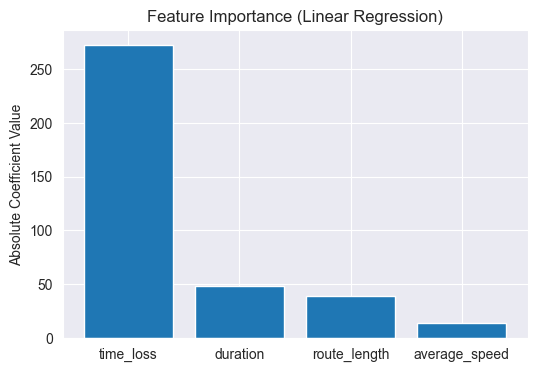

In [5]:
# bar plot
plt.figure(figsize=(6,4))
plt.bar(coefficients["Feature"], coefficients["Absolute Importance"])
plt.title("Feature Importance (Linear Regression)")
plt.ylabel("Absolute Coefficient Value")
plt.show()


In [6]:
# 10️. Predict congestion 

results_df = pd.DataFrame({
    "Vehicle ID": df.loc[test_idx, "vehicle_id"],
    "Actual Waiting Time": y_test,
    "Predicted Waiting Time": y_test_pred
})

# Mark high congestion if predicted waiting time is in top 25%
results_df["High Congestion"] = results_df["Predicted Waiting Time"] > results_df["Predicted Waiting Time"].quantile(0.75)
print("\nSample predictions with congestion flag:")
print(results_df.head()) 


Sample predictions with congestion flag:
      Vehicle ID  Actual Waiting Time  Predicted Waiting Time  High Congestion
674          949                  0.0                1.128868            False
1626        1977                343.0              367.591337             True
543          709                136.0              127.560754            False
506          618                138.0              139.703139            False
873          930                203.0              243.634286             True


In [7]:
df.loc[1161, "vehicle_id"]

np.int64(1278)